# Week 1: Churn Prediction Pipeline
## Day 6: ARPU Analysis, Priority Scoring and Customer Segmentation
**Goal:** Calculate customer value (ARPU), identify the highest priority churners and segment customers into 4 actionable groups using KMeans

**Dataset:** Telco Customer Churn — 7,043 customers
**Author:** Martin James| github.com/M20Jay

## Section 1 -Import Libraries

In [1]:
# Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import joblib
import psycopg2
from sqlalchemy import create_engine
import warnings
warnings.filterwarnings("ignore")

print("✅ All imports loaded")


✅ All imports loaded


## Section 2 — Load Data from PostgreSQL


In [2]:

# Connect to churn_db
engine = create_engine('postgresql://postgres:@localhost:5432/churn_db')

#Load raw data
df = pd.read_sql("SELECT * FROM churn_raw", engine)

#Load predictions made by Flask API

preds= pd.read_sql("SELECT customer_id, churn_probability FROM churn_predictions", engine)

print(f"Raw data: {df.shape}")

print(f"Predictions_loaded: {preds.shape}")
print(df.head(3))

Raw data: (7043, 23)
Predictions_loaded: (10, 2)
      id customer_id  gender  senior_citizen partner dependents  tenure  \
0  14087  7590-VHVEG  Female               0     Yes         No       1   
1  14088  5575-GNVDE    Male               0      No         No      34   
2  14089  3668-QPYBK    Male               0      No         No       2   

  phone_service    multiple_lines internet_service  ... tech_support  \
0            No  No phone service              DSL  ...           No   
1           Yes                No              DSL  ...           No   
2           Yes                No              DSL  ...           No   

  streaming_tv streaming_movies        contract paperless_billing  \
0           No               No  Month-to-month               Yes   
1           No               No        One year                No   
2           No               No  Month-to-month               Yes   

     payment_method monthly_charges total_charges churn  \
0  Electronic check      

## Section 3 — ARPU Calculation

In [3]:
# Fix total_charges — some rows come in as empty string from CSV
df['total_charges'] =  pd.to_numeric(df['total_charges'], errors = 'coerce')
df['total_charges'] = df['total_charges'].fillna(df['total_charges'])

# ARPU — same formula we used in training
df['arpu'] = df['total_charges'] / (df['tenure'] + 1)

# Quick look
print(df[['customer_id', 'tenure', 'total_charges', 'arpu']].head(5))
print(f"\nARPU range: ${df['arpu'].min():.2f} → ${df['arpu'].max():.2f}")
print(f"Mean ARPU: ${df['arpu'].mean():.2f}")

  customer_id  tenure  total_charges       arpu
0  7590-VHVEG       1          29.85  14.925000
1  5575-GNVDE      34        1889.50  53.985714
2  3668-QPYBK       2         108.15  36.050000
3  7795-CFOCW      45        1840.75  40.016304
4  9237-HQITU       2         151.65  50.550000

ARPU range: $0.00 → $118.97
Mean ARPU: $58.99


## Section 4 -  Merge with Predictions

In [4]:
# Drop only probability columns — NOT arpu
cols_to_drop = [c for c in ['churn_probability', 
                'churn_probability_x', 
                'churn_probability_y', 
                'priority_score', 
                'priority_socre'] if c in df.columns]
df = df.drop(columns=cols_to_drop)

# Merge churn_probability into main df
df = df.merge(preds, on='customer_id', how='left')

# Fill customers not yet scored with 0
df['churn_probability'] = df['churn_probability'].fillna(0)

# Priority Score
df['priority_score'] = df['churn_probability'] * df['arpu']

print(f"Customers with priority score: {df['priority_score'].notna().sum()}")
df[['customer_id', 'arpu', 'churn_probability', 'priority_score']].sort_values(
    'priority_score', ascending=False
).head(10)

Customers with priority score: 7043


,customer_id,arpu,churn_probability,priority_score
0,7590-VHVEG,14.925000,0.0,0.0
4691,3791-LGQCY,99.790351,0.0,0.0
4702,6008-NAIXK,53.944545,0.0,0.0
4701,5956-YHHRX,103.265909,0.0,0.0
4700,5365-LLFYV,35.200000,0.0,0.0
4699,5855-EIBDE,103.487000,0.0,0.0
4698,8166-ZZTFS,78.583582,0.0,0.0
4697,0129-KPTWJ,92.429452,0.0,0.0
4696,9128-CPXKI,94.257500,0.0,0.0
4695,9509-MPYOD,19.456944,0.0,0.0


## Section 5 - KMeans Segmentation

In [5]:
# Features for clustering
cluster_features = df[['arpu', 'churn_probability']].copy()

# Scale — KMeans needs this
scaler = StandardScaler()
X_scaled = scaler.fit_transform(cluster_features)

# KMeans — 4 clusters
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

# See cluster centers
cluster_centers = pd.DataFrame(scaler.inverse_transform(kmeans.cluster_centers_), 
columns=['arpu_center', 'prob_center'])

print(cluster_centers)
print(f"\nCluster counts:\n{df['cluster'].value_counts()}")

   arpu_center  prob_center
0    20.051214          0.0
1    73.689663          0.0
2    98.423736          0.0
3    47.574336          0.0

Cluster counts:
cluster
0    1975
1    1851
2    1693
3    1524
Name: count, dtype: int64


## Section 6 - Label the clusters

In [6]:
# Map cluster numbers to business names
# Based on arpu_center values we just saw
cluster_labels = {
    0: 'Low Value Loyal',
    1: 'High Value Loyal',
    2: 'High Value At Risk',
    3: 'Low Value At Risk'
}

df['segment'] = df['cluster'].map(cluster_labels)

print((df['segment'].value_counts()))

segment
Low Value Loyal       1975
High Value Loyal      1851
High Value At Risk    1693
Low Value At Risk     1524
Name: count, dtype: int64


## Section 7 - Visualise the Segments

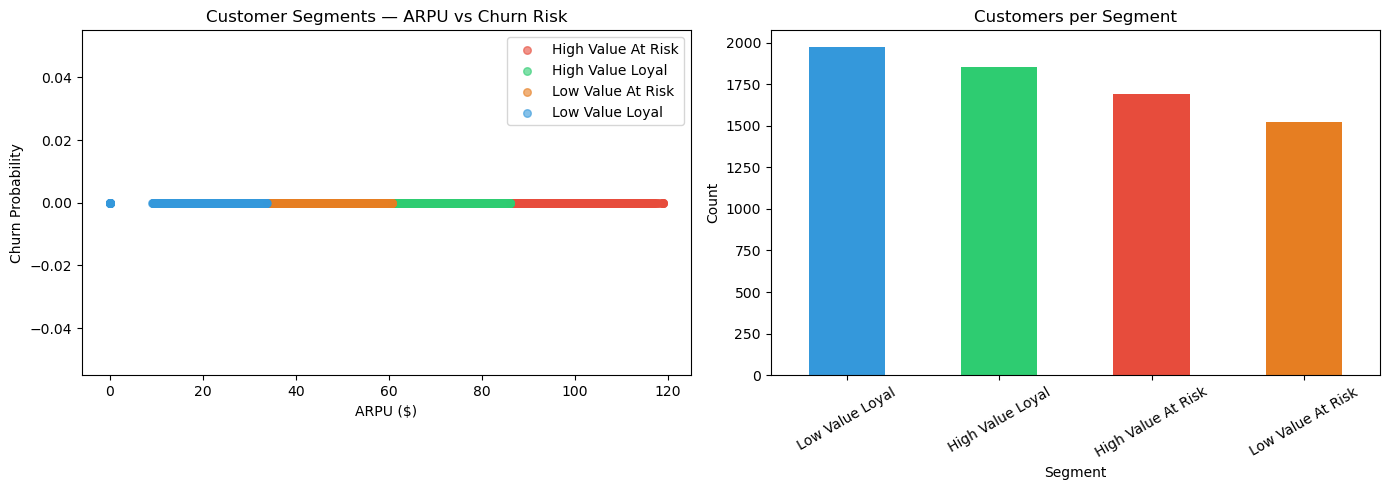

✅ Plot saved to reports/


In [7]:
#visuals
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = {
    'High Value At Risk': '#e74c3c',
    'High Value Loyal':   '#2ecc71',
    'Low Value At Risk':  '#e67e22',
    'Low Value Loyal':    '#3498db'
}

# Scatter plot
for segment, group in df.groupby('segment'):
    axes[0].scatter(
        group['arpu'],
        group['churn_probability'],
        label=segment,
        color=colors.get(segment, 'gray'),
        alpha=0.6, s=30
    )

axes[0].set_xlabel('ARPU ($)')
axes[0].set_ylabel('Churn Probability')
axes[0].set_title('Customer Segments — ARPU vs Churn Risk')
axes[0].legend()

# Bar chart
df['segment'].value_counts().plot(
    kind='bar', ax=axes[1],
    color=[colors.get(s, 'gray') for s in df['segment'].value_counts().index]
)
axes[1].set_title('Customers per Segment')
axes[1].set_xlabel('Segment')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('reports/arpu_segmentation.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot saved to reports/")


## Section 8 - Save to PostgreSQL

In [9]:
# Saving work
segment_df = df[['customer_id', 'arpu', 
                  'churn_probability', 
                  'priority_score', 
                  'segment']].copy()

segment_df.to_sql(
    'churn_segments',
    engine,
    if_exists='replace',
    index=False
)
print(f"✅ {len(segment_df)} customers saved to churn_segments table")

✅ 7043 customers saved to churn_segments table
